<a href="https://colab.research.google.com/github/elenann-cpu/Privacy-security-trust-ML-systems/blob/main/Task_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank-additional.zip"
!wget $url

!unzip -o bank-additional.zip

df = pd.read_csv('bank-additional/bank-additional-full.csv', sep=';')

print("Status: Dataset downloaded and loaded into memory.")

--2026-05-18 15:25:44--  https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank-additional.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘bank-additional.zip’

bank-additional.zip     [  <=>               ] 434.15K  1.77MB/s    in 0.2s    

2026-05-18 15:25:45 (1.77 MB/s) - ‘bank-additional.zip’ saved [444572]

Archive:  bank-additional.zip
   creating: bank-additional/
  inflating: bank-additional/.DS_Store  
   creating: __MACOSX/
   creating: __MACOSX/bank-additional/
  inflating: __MACOSX/bank-additional/._.DS_Store  
  inflating: bank-additional/.Rhistory  
  inflating: bank-additional/bank-additional-full.csv  
  inflating: bank-additional/bank-additional-names.txt  
  inflating: bank-additional/bank-additional.csv  
  inflating: __MACOSX/._bank-additional  
Status: Dataset

# **Binary, Laplace and Exponential mechanisms**

# **Bank Dataset Loading**

In [ ]:
df = pd.read_csv('bank-additional/bank-additional-full.csv', sep=';')

print(f"Dataset loaded! Shape: ({df.shape[0]}, {df.shape[1]})")

df.head(10)

Dataset loaded! Shape: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
5,45,services,married,basic.9y,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
6,59,admin.,married,professional.course,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
7,41,blue-collar,married,unknown,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
8,24,technician,single,professional.course,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
9,25,services,single,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [ ]:
import requests
import io
import zipfile

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank.zip"
response = requests.get(url)
z = zipfile.ZipFile(io.BytesIO(response.content))
bank = pd.read_csv(z.open('bank.csv'), sep=";")

# **Laplace Mechanism**

 Listing 2.1 Counting query - How many individuals in the bank dataset are more than 40 years old?

In [ ]:
count = len([age for age in bank['age'] if age > 40])

print(count)

2089


Listing 2.1 (continued): Differentially Private Counting Query with ε = [0.1, 0.5, 1.0, 5.0]

In [ ]:
sensitivity = 1
epsilon = 0.1

true_count = bank['age'].gt(40).sum()

noise = np.random.laplace(loc=0, scale=sensitivity/epsilon)
count = true_count + noise

print(f"Noisy result: {count}")

Noisy result: 2076.948940852415


In [ ]:
sensitivity = 1
epsilon = 0.5

true_count = bank['age'].gt(40).sum()

noise = np.random.laplace(loc=0, scale=sensitivity/epsilon)
count = true_count + noise

print(f"Noisy result: {count}")

Noisy result: 2086.6926855557613


In [ ]:
sensitivity = 1
epsilon = 1.0

true_count = bank['age'].gt(40).sum()

noise = np.random.laplace(loc=0, scale=sensitivity/epsilon)
count = true_count + noise

print(f"Noisy result: {count}")

Noisy result: 2087.334366539846


In [ ]:
sensitivity = 1
epsilon = 5.0

true_count = bank['age'].gt(40).sum()

noise = np.random.laplace(loc=0, scale=sensitivity/epsilon)
count = true_count + noise

print(f"Noisy result: {count}")

Noisy result: 2089.1351471244657


Listing 2.2: Histogram Query without DP

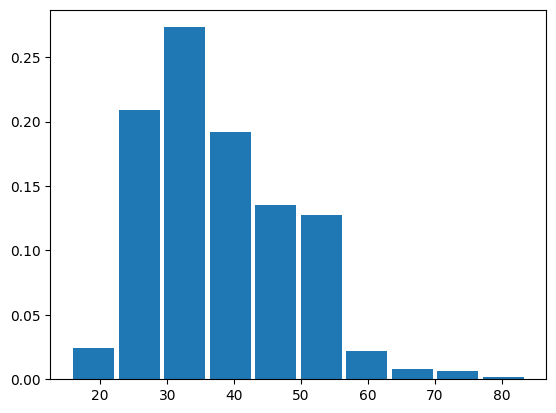

In [ ]:
bank_ages = bank['age'].values

hist, bins = np.histogram(bank_ages)
hist = hist / hist.sum()
plt.bar(bins[:-1], hist, width=(bins[1]-bins[0]) * 0.9)
plt.show()

Listing 2.3: DP Version of the Histogram Query

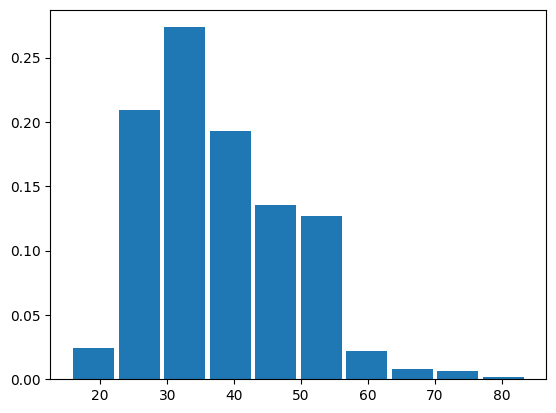

In [ ]:
!pip install diffprivlib
from diffprivlib.mechanisms import Laplace
import numpy as np
import matplotlib.pyplot as plt

def histogram_laplace(sample, epsilon=1, bins=10, range=None, normed=None, weights=None, density=None):
    hist, bin_edges = np.histogram(sample, bins=bins, range=range, weights=weights, density=None)

    dp_mech = Laplace(epsilon=1, sensitivity=1)
    dp_hist = np.zeros_like(hist)
    for i in np.arange(dp_hist.shape[0]):
        dp_hist[i] = dp_mech.randomise(int(hist[i]))
    if normed or density:
        bin_sizes = np.array(np.diff(bin_edges), float)
        return dp_hist / bin_sizes / dp_hist.sum(), bin_edges
    return dp_hist, bin_edges

dp_hist, dp_bins = histogram_laplace(bank['age'].values, epsilon=0.01)
dp_hist = dp_hist / dp_hist.sum()

plt.bar(dp_bins[:-1], dp_hist, width=(dp_bins[1] - dp_bins[0]) * 0.9)
plt.show()

# **Exponential Mechanism**

Listing 2.4: Number of People in Each Marital Status Group (Bank Dataset)

In [ ]:
print("married: " + str(len([i for i in bank['marital'] if i == 'married'])))
print("single: " + str(len([i for i in bank['marital'] if i == 'single'])))
print("divorced: " + str(len([i for i in bank['marital'] if i == 'divorced'])))

married: 2797
single: 1196
divorced: 528


Listing 2.5 Differentially Private Most Common Marital Status Using Exponential Mechanism (Bank Dataset)

In [ ]:
import numpy as np
import pandas as pd

sets = bank['marital'].unique()

def utility(data, categories):
    counts = data.value_counts()
    return np.array([counts.get(cat, 0) for cat in categories])

def exponential_mechanism(x, A, H, sensitivity, epsilon):
    utilities = H(x, A)

    utilities = utilities / np.max(utilities)

    utilities = utilities - np.max(utilities)

    scores = np.exp((epsilon * utilities) / (2 * sensitivity))

    probabilities = scores / np.sum(scores)

    return np.random.choice(A, p=probabilities)

print("--- Single Query Result ---")
result = exponential_mechanism(bank['marital'], sets, utility, 1, 1)
print("Result:", result)

print("\n--- Running 10,000 Simulations ---")

res = [
    exponential_mechanism(bank['marital'], sets, utility, 1, 1)
    for _ in range(10000)
]

print(pd.Series(res).value_counts())

--- Single Query Result ---
Result: single

--- Running 10,000 Simulations ---
married     4018
single      3268
divorced    2714
Name: count, dtype: int64


In [ ]:
epsilons = [0.1, 5, 10]

for eps in epsilons:
    print(f"\n--- Epsilon = {eps} ---")

    res = [
        exponential_mechanism(bank['marital'], sets, utility, 1, eps)
        for _ in range(10000)
    ]

    print(pd.Series(res).value_counts())


--- Epsilon = 0.1 ---
married     3381
single      3370
divorced    3249
Name: count, dtype: int64

--- Epsilon = 5 ---
married     7310
single      1713
divorced     977
Name: count, dtype: int64

--- Epsilon = 10 ---
married     9306
single       524
divorced     170
Name: count, dtype: int64


# **Binary Mechanism**

In [ ]:
df['is_married'] = (df['marital'] == 'married').astype(int)

In [ ]:
import numpy as np

def randomized_response(x, p):
    if np.random.rand() < p:
        return x
    else:
        return 1 - x

In [ ]:
def dp_binary_query(data, p):
    return np.array([randomized_response(x, p) for x in data])

In [ ]:
def epsilon_to_p(epsilon):
    return np.exp(epsilon) / (1 + np.exp(epsilon))

In [ ]:
epsilons = [0.1, 1.0, 5.0, 10.0]

true_married_percent = df['is_married'].mean()

print(f"True percentage of married users: {true_married_percent:.4f}\n")

for eps in epsilons:
    p = epsilon_to_p(eps)

    noisy_results = dp_binary_query(df['is_married'].values, p)

    noisy_mean = np.mean(noisy_results)

    corrected_estimate = (noisy_mean + p - 1) / (2 * p - 1)

    final_estimate = np.clip(corrected_estimate, 0, 1)

    print(f"ε = {eps} (p = {p:.3f}) ---")
    print(f"   Estimated % married: {final_estimate:.4f}")
    print(f"   Error: {abs(true_married_percent - final_estimate):.4f}\n")

True percentage of married users: 0.6052

ε = 0.1 (p = 0.525) ---
   Estimated % married: 0.5637
   Error: 0.0416

ε = 1.0 (p = 0.731) ---
   Estimated % married: 0.6051
   Error: 0.0001

ε = 5.0 (p = 0.993) ---
   Estimated % married: 0.6054
   Error: 0.0002

ε = 10.0 (p = 1.000) ---
   Estimated % married: 0.6053
   Error: 0.0000



# **Listing 2.7: Applying Sequential Composition**

In [ ]:
true_value = np.sum(bank['marital'] == 'married')
sensitivity = 1

In [ ]:
epsilon1 = 0.1
epsilon2 = 0.2
epsilon3 = epsilon1 + epsilon2

def F1(x):
    return x + np.random.laplace(0, sensitivity/epsilon1)

def F2(x):
    return x + np.random.laplace(0, sensitivity/epsilon2)

def F3(x):
    return x + np.random.laplace(0, sensitivity/epsilon3)

In [ ]:
def F_seq(x):
    return (F1(x) + F2(x)) / 2

In [ ]:
print("True value:", true_value)

results_f1 = [F1(true_value) for _ in range(1000)]
results_f2 = [F2(true_value) for _ in range(1000)]
results_f3 = [F3(true_value) for _ in range(1000)]
results_seq = [F_seq(true_value) for _ in range(1000)]

print("\n--- Averages ---")
print("F1 mean:", np.mean(results_f1))
print("F2 mean:", np.mean(results_f2))
print("F3 mean:", np.mean(results_f3))
print("F_seq mean:", np.mean(results_seq))

True value: 2797

--- Averages ---
F1 mean: 2797.5039424705506
F2 mean: 2797.3944089375796
F3 mean: 2797.1662413642302
F_seq mean: 2796.935534643681


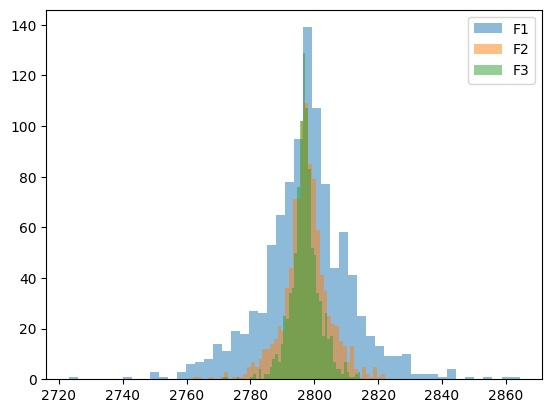

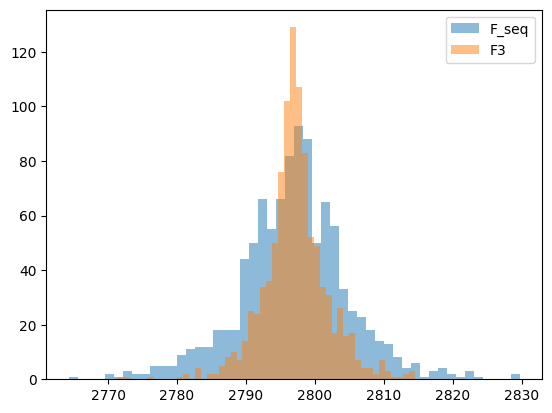

In [ ]:
plt.hist(results_f1, bins=50, alpha=0.5, label="F1")
plt.hist(results_f2, bins=50, alpha=0.5, label="F2")
plt.hist(results_f3, bins=50, alpha=0.5, label="F3")
plt.legend()
plt.show()

plt.hist(results_seq, bins=50, alpha=0.5, label="F_seq")
plt.hist(results_f3, bins=50, alpha=0.5, label="F3")
plt.legend()
plt.show()